In [33]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve
)
from xgboost import XGBClassifier
import joblib
import shap

import warnings
warnings.filterwarnings("ignore")

In [4]:
#Load dataset
df=pd.read_csv(r"E:\Imarticus\capstone\cp2\ai4i+2020+predictive+maintenance+dataset\ai4i2020.csv")

In [5]:
#Data understanding
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
df.shape

(10000, 14)

In [7]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [9]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [10]:
#main features
features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

target = "Machine failure"

In [11]:
#Data quality check
#Missing values
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [12]:
#Duplicate values
df.duplicated().sum()

np.int64(0)

In [13]:
#Target distribution
df[target].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [14]:
df[target].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

In [15]:
#Remove unnecessary columns
data = df[features + [target]].copy()

In [16]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [17]:
data.shape

(10000, 6)

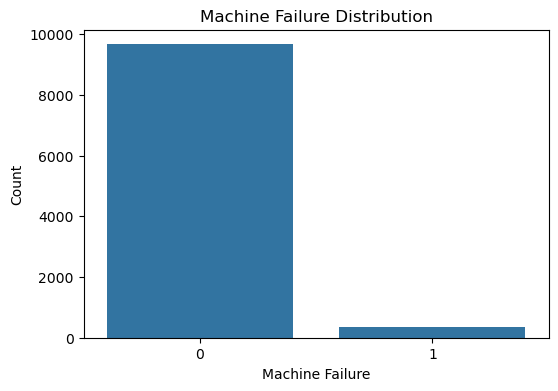

In [18]:
#EDA
#Failure distribution
plt.figure(figsize=(6,4))

sns.countplot(x=target, data=data)

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Count")
plt.show()

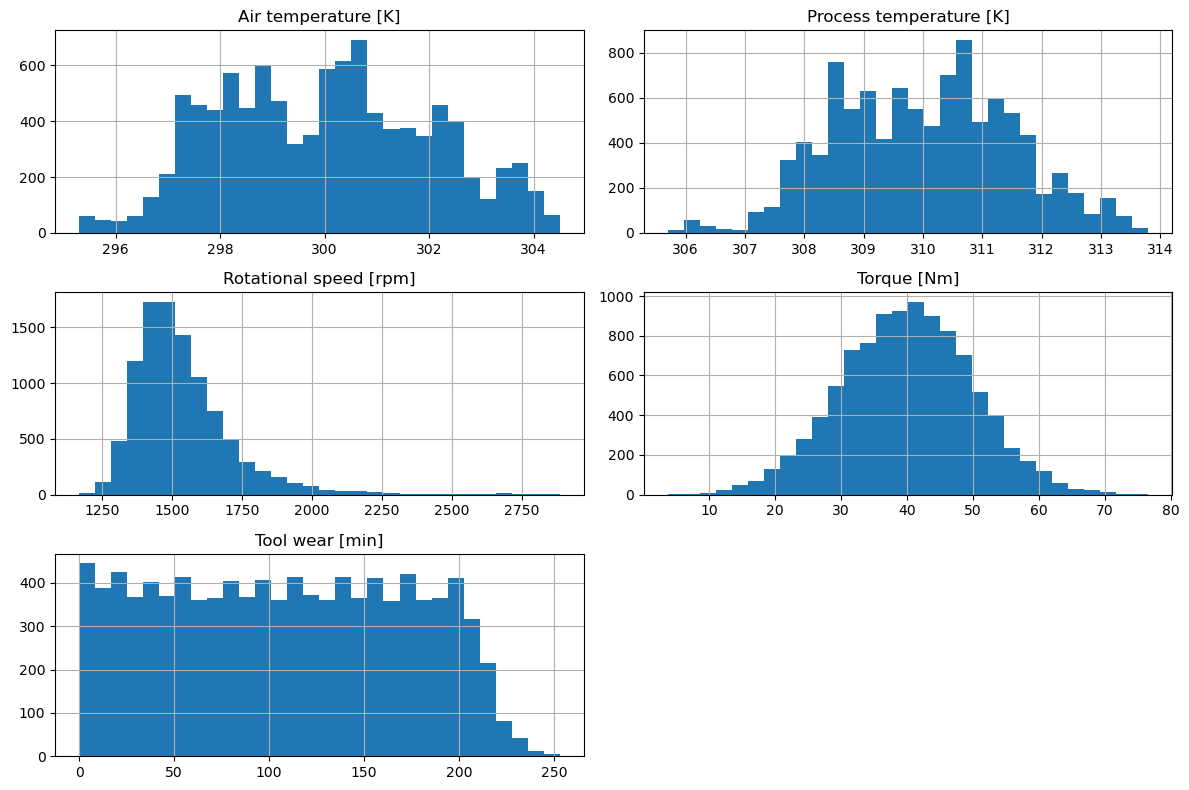

In [19]:
#Feature distributions
data[features].hist(figsize=(12,8),bins=30)
plt.tight_layout()
plt.show()

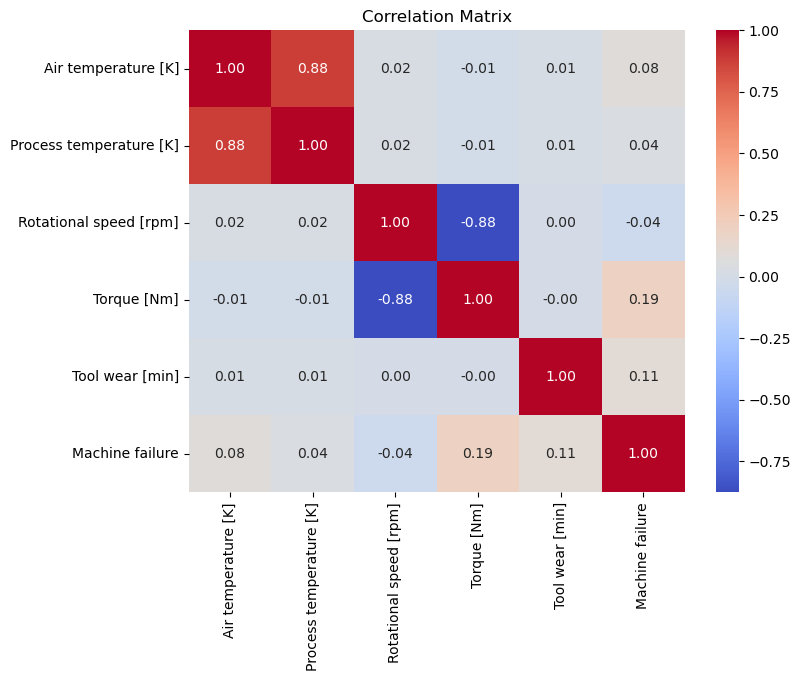

In [20]:
#Correlation
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

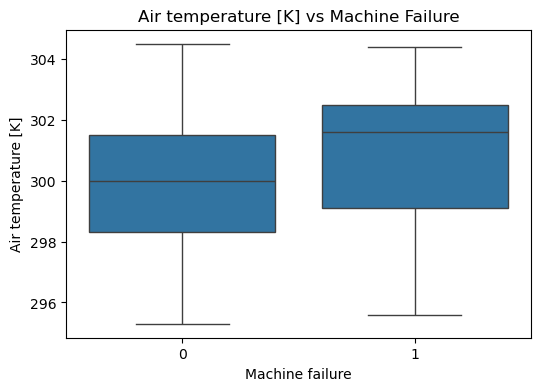

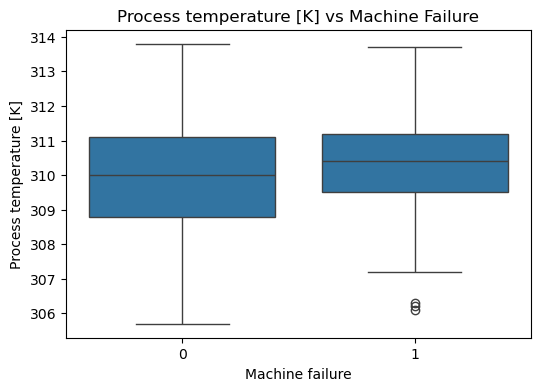

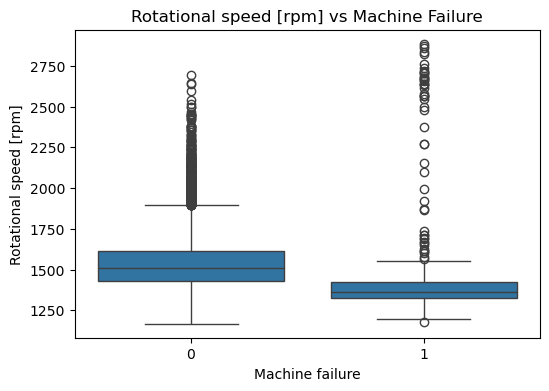

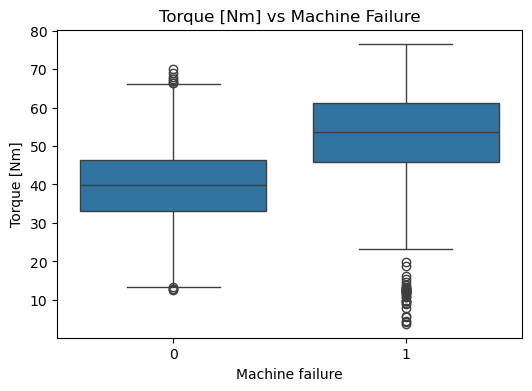

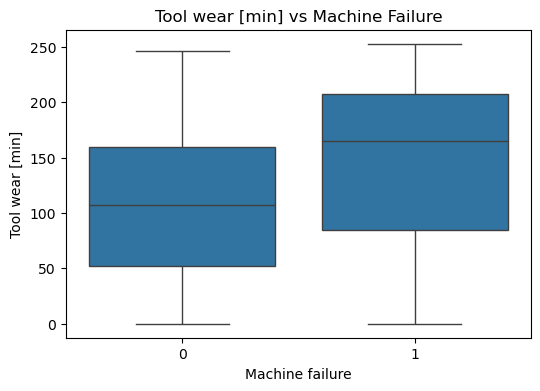

In [21]:
#Failure vs parameters
for feature in features:

    plt.figure(figsize=(6,4))
    sns.boxplot(x=target,y=feature,data=data)
    plt.title(f"{feature} vs Machine Failure")
    plt.show()

In [22]:
data = df[features + [target]].copy()

In [23]:
data.shape

(10000, 6)

In [24]:
# Separate input features and target

X = data[features]
y = data[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 5)
y shape: (10000,)


In [25]:
# Train-Test Split
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check the shape of training and testing data
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 5)
X_test: (2000, 5)
y_train: (8000,)
y_test: (2000,)


In [26]:
# Model Training
# Create the Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000)

# Train the model using training data
logistic_model.fit(X_train, y_train)

# Predict machine failure on test data
y_pred = logistic_model.predict(X_test)

# Display the predictions
print("Model training completed successfully.")

Model training completed successfully.


In [27]:
# Model Evaluation
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

# Display the evaluation results
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.969
Precision: 0.6875
Recall   : 0.16176470588235295
F1 Score : 0.2619047619047619


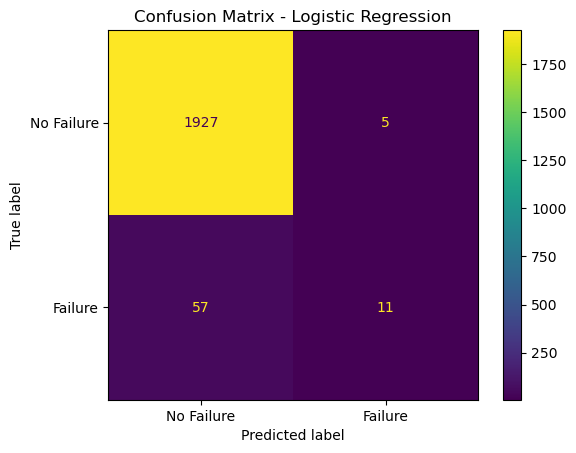

In [28]:
# Confusion Matrix
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Failure", "Failure"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [29]:
# Random Forest Model
# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on test data
y_pred_rf = rf_model.predict(X_test)

# Model training completed
print("Random Forest training completed successfully.")

Random Forest training completed successfully.


In [30]:
# Random Forest Model Evaluation

# Calculate evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)

# Display evaluation results
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

Accuracy : 0.985
Precision: 0.8958333333333334
Recall   : 0.6323529411764706
F1 Score : 0.7413793103448276


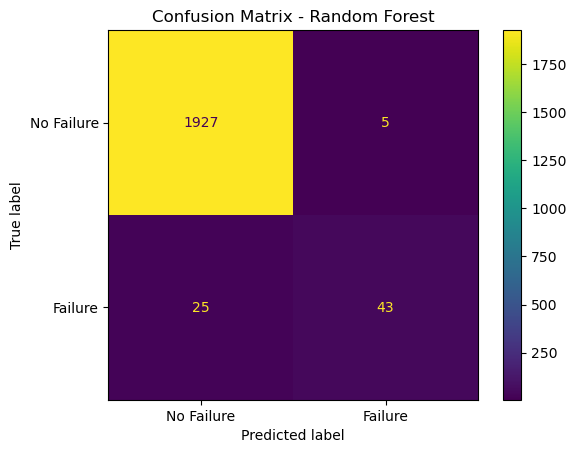

In [31]:
# Random Forest Confusion Matrix

# Calculate confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Failure", "Failure"]
)

disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [36]:
# Check target values

print("y_train unique values:", np.unique(y_train))
print("y_test unique values:", np.unique(y_test))

y_train unique values: [0 1]
y_test unique values: [0 1]


In [37]:
# Clean feature names for XGBoost

X_train = X_train.copy()
X_test = X_test.copy()

X_train.columns = (
    X_train.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "", regex=False)
)

X_test.columns = (
    X_test.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "", regex=False)
)

print("Feature names cleaned successfully.")
print(X_train.columns)

Feature names cleaned successfully.
Index(['Air temperature K', 'Process temperature K', 'Rotational speed rpm',
       'Torque Nm', 'Tool wear min'],
      dtype='object')


In [38]:
# XGBoost Model
# Create XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
xgb_model.fit(X_train, y_train)

# Predict on test data
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost training completed successfully.")

XGBoost training completed successfully.


In [39]:
# XGBoost Model Evaluation

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb, zero_division=0)
recall_xgb = recall_score(y_test, y_pred_xgb, zero_division=0)
f1_xgb = f1_score(y_test, y_pred_xgb, zero_division=0)

print("Accuracy :", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall   :", recall_xgb)
print("F1 Score :", f1_xgb)

Accuracy : 0.985
Precision: 0.8392857142857143
Recall   : 0.6911764705882353
F1 Score : 0.7580645161290323


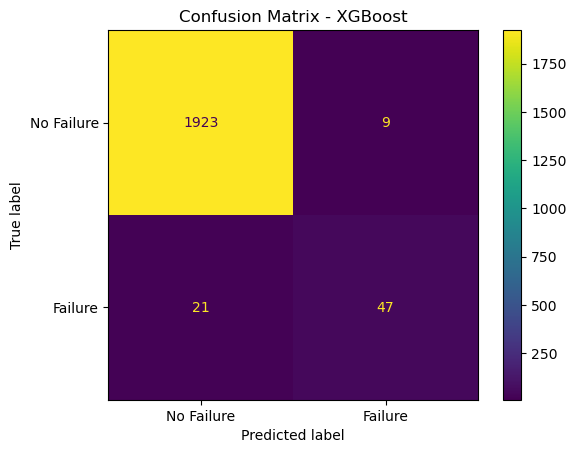

In [40]:
# XGBoost Confusion Matrix

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["No Failure", "Failure"]
)

disp.plot()
plt.title("Confusion Matrix - XGBoost")
plt.show()

In [41]:
# Model Comparison

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [accuracy, accuracy_rf, accuracy_xgb],
    "Precision": [precision, precision_rf, precision_xgb],
    "Recall": [recall, recall_rf, recall_xgb],
    "F1 Score": [f1, f1_rf, f1_xgb]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.969,0.687500,0.161765,0.261905
1,Random Forest,0.985,0.895833,0.632353,0.741379
2,XGBoost,0.985,0.839286,0.691176,0.758065


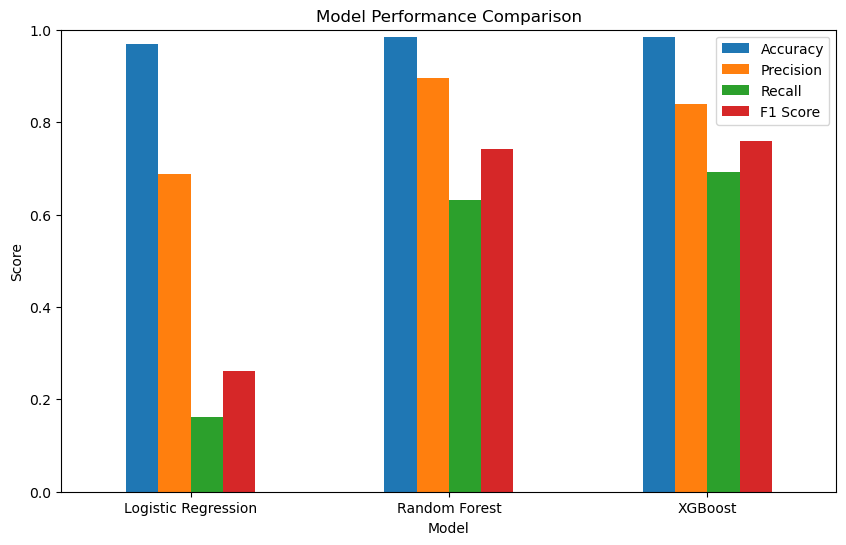

In [42]:
# Model Comparison Visualization

model_comparison.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [43]:
# XGBoost Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                 Feature  Importance
3              Torque Nm    0.373667
0      Air temperature K    0.195265
4          Tool wear min    0.178552
1  Process temperature K    0.131602
2   Rotational speed rpm    0.120915


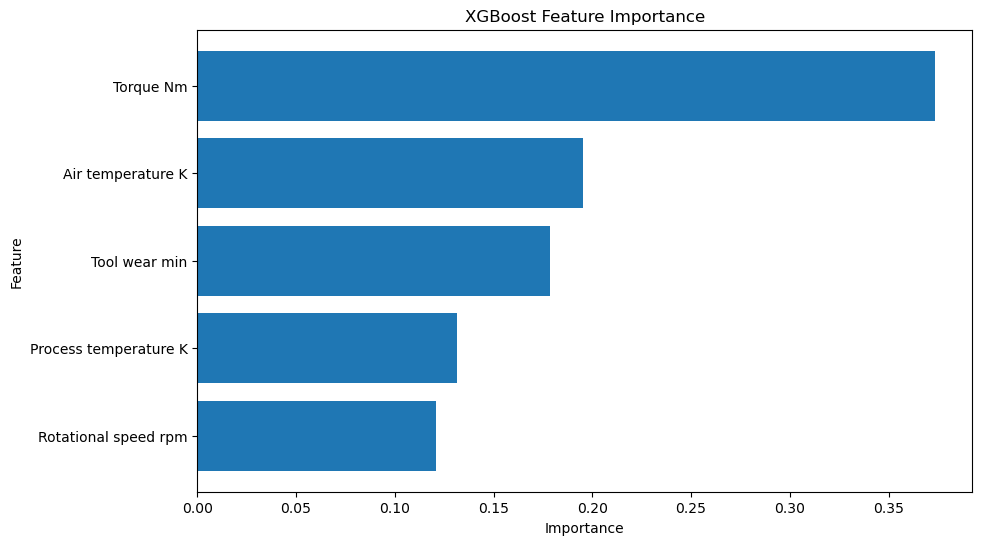

In [44]:
# XGBoost Feature Importance Visualization

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()

plt.show()

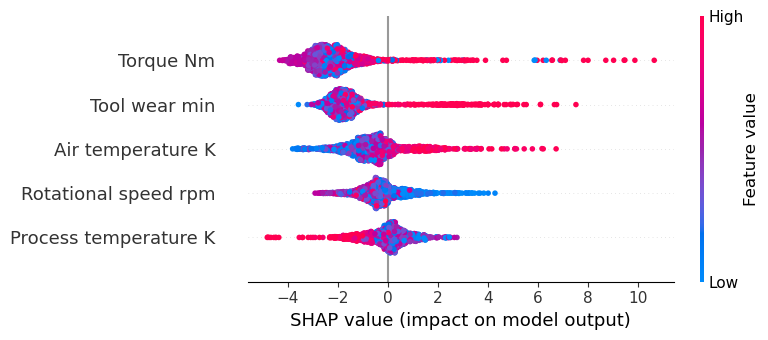

In [45]:
# SHAP Analysis
# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot
shap.summary_plot(shap_values, X_test)

In [46]:
# Final Model Selection

best_model = "XGBoost"

print("Best Model:", best_model)
print("Accuracy:", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall:", recall_xgb)
print("F1 Score:", f1_xgb)

print("\nConclusion:")
print("XGBoost is selected as the best model because it achieved the highest Recall and F1 Score.")

Best Model: XGBoost
Accuracy: 0.985
Precision: 0.8392857142857143
Recall: 0.6911764705882353
F1 Score: 0.7580645161290323

Conclusion:
XGBoost is selected as the best model because it achieved the highest Recall and F1 Score.


In [47]:
# Save Final XGBoost Model

import joblib

joblib.dump(xgb_model, "xgboost_machine_failure_model.pkl")

print("XGBoost model saved successfully.")

XGBoost model saved successfully.


In [48]:
# Test Final Model Prediction

sample_prediction = xgb_model.predict(X_test.iloc[:5])

print("Predicted values:", sample_prediction)
print("Actual values:", y_test.iloc[:5].values)

Predicted values: [0 0 0 0 0]
Actual values: [0 0 0 0 0]


In [49]:

joblib.dump(xgb_model, "xgb_machine_failure_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [50]:
%%writefile app.py

from flask import Flask, request, render_template
import joblib
import pandas as pd

app = Flask(__name__)

# Load trained model
model = joblib.load("xgb_machine_failure_model.pkl")


@app.route("/")
def home():
    return render_template("index.html")


@app.route("/predict", methods=["POST"])
def predict():

    air_temperature = float(request.form["air_temperature"])
    process_temperature = float(request.form["process_temperature"])
    rotational_speed = float(request.form["rotational_speed"])
    torque = float(request.form["torque"])
    tool_wear = float(request.form["tool_wear"])

    input_data = pd.DataFrame([[
        air_temperature,
        process_temperature,
        rotational_speed,
        torque,
        tool_wear
    ]], columns=[
        "Air temperature K",
        "Process temperature K",
        "Rotational speed rpm",
        "Torque Nm",
        "Tool wear min"
    ])

    prediction = model.predict(input_data)[0]

    if prediction == 1:
        result = "Machine Failure Detected"
    else:
        result = "No Machine Failure"

    return render_template("index.html", prediction=result)


if __name__ == "__main__":
    app.run(debug=True)

Writing app.py


In [51]:
%%writefile index.html

<!DOCTYPE html>
<html>
<head>
    <title>Machine Failure Prediction</title>
</head>

<body>

    <h1>Machine Failure Prediction</h1>

    <form action="/predict" method="POST">

        <label>Air Temperature (K):</label>
        <input type="number" step="any" name="air_temperature" required>
        <br><br>

        <label>Process Temperature (K):</label>
        <input type="number" step="any" name="process_temperature" required>
        <br><br>

        <label>Rotational Speed (rpm):</label>
        <input type="number" step="any" name="rotational_speed" required>
        <br><br>

        <label>Torque (Nm):</label>
        <input type="number" step="any" name="torque" required>
        <br><br>

        <label>Tool Wear (min):</label>
        <input type="number" step="any" name="tool_wear" required>
        <br><br>

        <button type="submit">Predict</button>

    </form>

    {% if prediction %}
        <h2>Result: {{ prediction }}</h2>
    {% endif %}

</body>
</html>

Writing index.html


In [54]:
failure_cases = df[df["Machine failure"] == 1]

print(failure_cases)

       UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
50      51     L47230    L                298.9                    309.1   
69      70     L47249    L                298.9                    309.0   
77      78     L47257    L                298.8                    308.9   
160    161     L47340    L                298.4                    308.2   
161    162     L47341    L                298.3                    308.1   
...    ...        ...  ...                  ...                      ...   
9758  9759     L56938    L                298.6                    309.8   
9764  9765     L56944    L                298.5                    309.5   
9822  9823     L57002    L                298.5                    309.4   
9830  9831     L57010    L                298.3                    309.3   
9974  9975     L57154    L                298.6                    308.2   

      Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  \
50      

In [55]:
failure_cases[
    [
        "UDI",
        "Product ID",
        "Type",
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]",
        "Machine failure"
    ]
]

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
50,51,L47230,L,298.9,309.1,2861,4.6,143,1
69,70,L47249,L,298.9,309.0,1410,65.7,191,1
77,78,L47257,L,298.8,308.9,1455,41.3,208,1
160,161,L47340,L,298.4,308.2,1282,60.7,216,1
161,162,L47341,L,298.3,308.1,1412,52.3,218,1
...,...,...,...,...,...,...,...,...,...
9758,9759,L56938,L,298.6,309.8,2271,16.2,218,1
9764,9765,L56944,L,298.5,309.5,1294,66.7,12,1
9822,9823,L57002,L,298.5,309.4,1360,60.9,187,1
9830,9831,L57010,L,298.3,309.3,1337,56.1,206,1


In [59]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\rashn\Documents\CP2
['.ipynb_checkpoints', 'app.py', 'Machine_Failure_Analysis.ipynb', 'streamlit_app.py', 'templates', 'xgboost_machine_failure_model.pkl', 'xgb_machine_failure_model.pkl']
